In [1]:
import polars as pl
import numpy as np
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt

def impute_execution_time(df, target_model):
    """
    Imputa los tiempos nulos de un modelo usando extrapolación de Ley de Potencias (O(n^b)).
    """
    
    # 1. Separar datos del modelo objetivo
    df_model = df.filter(pl.col("model_name") == target_model)
    
    # 2. Separar los casos con tiempo conocido y los nulos
    df_train = df_model.filter(pl.col("mean_time").is_not_null())
    df_nulls = df_model.filter(pl.col("mean_time").is_null())
    
    if df_train.height < 2:
        print(f"No hay suficientes datos válidos para entrenar la regresión de {target_model}")
        return df
        
    # 3. Preparar los datos para la regresión log-log
    # Usamos n_rows (y opcionalmente podríamos multiplicar por n_cols si varía mucho)
    X_train = np.log(df_train["n_rows"].to_numpy().reshape(-1, 1))
    y_train = np.log(df_train["mean_time"].to_numpy())
    
    # Entrenar el modelo (log(Time) = b * log(n_rows) + log(a))
    reg = LinearRegression().fit(X_train, y_train)
    
    # (Opcional) Imprimir la complejidad empírica descubierta
    print(f"[{target_model}] Complejidad empírica estimada: O(N^{reg.coef_[0]:.2f})")
    
    # 4. Predecir para los valores nulos
    X_pred = np.log(df_nulls["n_rows"].to_numpy().reshape(-1, 1))
    y_pred_log = reg.predict(X_pred)
    y_pred_time = np.exp(y_pred_log) # Deshacer el logaritmo
    
    # 5. Crear un DataFrame temporal con las predicciones para hacer un "update"
    df_predictions = pl.DataFrame({
        "data_id": df_nulls["data_id"],
        "model_name": df_nulls["model_name"],
        "imputed_time": y_pred_time
    })
    
    # 6. Actualizar la tabla maestra original
    # Hacemos un JOIN y usamos coalesce para rellenar los nulos con imputed_time
    df = df.join(
        df_predictions, 
        on=["data_id", "model_name"], 
        how="left"
    ).with_columns(
        pl.coalesce(["mean_time", "imputed_time"]).alias("mean_time")
    ).drop("imputed_time")
    
    return df

In [2]:
import os, sys
import polars as pl
import matplotlib.pyplot as plt
import seaborn as sns


In [3]:
script_path = os.getcwd()
project_path = os.path.abspath(os.path.join(script_path, '..', '..', '..'))
results_dir = os.path.join(project_path, 'results', 'experiment_5')
results_save_path = os.path.join(results_dir, 'master_table_exp_5.parquet')

sys.path.append(project_path)
from src.utils.experiments_exploration_utils import plot_experiment_5_results

In [4]:
df_results = pl.read_parquet(results_save_path)

df_results = impute_execution_time(df=df_results, target_model="KMedoids-euclidean")

[KMedoids-euclidean] Complejidad empírica estimada: O(N^2.19)


In [5]:
df_results

model_name,mean_ari,mean_adj_accuracy,mean_time,std_ari,std_adj_accuracy,std_time,prop_status_error,data_id,n_rows,n_cols,n_clusters,separation_factor,n_quant,n_bin,n_multiclass,prop_categorical,mean_prop_outliers_quant,prop_high_corr_quant,sphericity_quant,prop_redundancy_quant,normalized_balance_entropy,is_balanced
str,f64,f64,f64,f64,f64,f64,f64,str,i64,i64,i64,f64,i64,i64,i64,f64,f64,f64,f64,f64,f64,bool
"""FoldFastKmedoidsGGower-robust_…",0.752012,0.888843,22.843773,0.109649,0.060864,6.216831,0.0,"""simulation_1""",35000,8,4,1.0,4,2,2,0.5,0.0282,0.1667,0.4402,0.25,1.0,true
"""FoldFastKmedoidsGGower-robust_…",0.741201,0.884982,22.728664,0.110318,0.058405,6.09416,0.0,"""simulation_1""",35000,8,4,1.0,4,2,2,0.5,0.0282,0.1667,0.4402,0.25,1.0,true
"""FoldFastKmedoidsGGower-robust_…",0.727507,0.876641,21.964127,0.113159,0.065658,5.882043,0.0,"""simulation_1""",35000,8,4,1.0,4,2,2,0.5,0.0282,0.1667,0.4402,0.25,1.0,true
"""MiniBatchKMeans""",0.764349,0.857945,0.51653,0.119469,0.110275,0.595529,0.0,"""simulation_1""",35000,8,4,1.0,4,2,2,0.5,0.0282,0.1667,0.4402,0.25,1.0,true
"""FastKmedoidsGGower-robust_maha…",0.671629,0.844168,21.482343,0.135074,0.080374,9.045525,0.0,"""simulation_1""",35000,8,4,1.0,4,2,2,0.5,0.0282,0.1667,0.4402,0.25,1.0,true
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""Diana""",0.001483,0.340178,9.84295,0.0,0.0,4.984466,0.0,"""kc_houses""",21597,15,3,null,12,0,3,0.2,0.0317,0.1515,0.0,0.8333,0.5743,false
"""Birch""",0.001525,0.339998,17.529177,0.0,0.0,5.526126,0.0,"""kc_houses""",21597,15,3,null,12,0,3,0.2,0.0317,0.1515,0.0,0.8333,0.5743,false
"""SpectralBiclustering""",0.003414,0.337691,0.795945,0.0,0.0,0.160709,0.0,"""kc_houses""",21597,15,3,null,12,0,3,0.2,0.0317,0.1515,0.0,0.8333,0.5743,false


In [6]:
def analyze_model_rankings(df):

    # Rankeamos en orden descendente (mayor ARI = rank 1)
    df_ranked = df.with_columns(
        pl.col("mean_adj_accuracy").rank(method="min", descending=True).over("data_id").alias("rank_in_dataset")
    )
    
    # 3. Agregación Global del Torneo
    df_rank = df_ranked.group_by("model_name").agg([
        pl.col("rank_in_dataset").mean().alias("mean_rank"),
        pl.col("rank_in_dataset").std().alias("std_rank"), # Alta std indica que es bueno en unos y malo en otros
        ((pl.col("rank_in_dataset") == 1).mean() * 100).alias("perc_top_1"),
        ((pl.col("rank_in_dataset") <= 3).mean() * 100).alias("perc_top_3"),
        pl.col("mean_adj_accuracy").mean().alias("global_mean_acc")
    ]).sort("mean_rank")
    
    return df_rank

In [7]:
df_rank = analyze_model_rankings(df_results)

In [8]:
df_rank

model_name,mean_rank,std_rank,perc_top_1,perc_top_3,global_mean_acc
str,f64,f64,f64,f64,f64
"""Dipinit""",null,null,null,null,null
"""FoldFastKmedoidsGGower-robust_…",4.4,3.657564,10.0,60.0,0.819228
"""FastKmedoidsGGower-robust_maha…",4.8,3.011091,30.0,30.0,0.80873
"""FoldFastKmedoidsGGower-robust_…",5.9,3.95671,0.0,40.0,0.811546
"""FoldFastKmedoidsGGower-robust_…",6.3,3.093003,0.0,20.0,0.807531
…,…,…,…,…,…
"""Diana""",20.5,4.434712,0.0,0.0,0.469835
"""AgglomerativeClustering""",20.75,2.629956,0.0,0.0,0.525131
"""SpectralBiclustering""",21.1,2.923088,0.0,0.0,0.586306


In [9]:
df_rank['model_name'].to_list()

['Dipinit',
 'FoldFastKmedoidsGGower-robust_mahalanobis_winsorized-sokal-hamming',
 'FastKmedoidsGGower-robust_mahalanobis_winsorized-sokal-hamming',
 'FoldFastKmedoidsGGower-robust_mahalanobis_trimmed-sokal-hamming',
 'FoldFastKmedoidsGGower-robust_mahalanobis_MAD-sokal-hamming',
 'FastKmedoidsGGower-robust_mahalanobis_trimmed-sokal-hamming',
 'MiniBatchKMeans',
 'FastKmedoidsGGower-robust_mahalanobis_winsorized-jaccard-hamming',
 'FoldFastKmedoidsGGower-robust_mahalanobis_winsorized-jaccard-hamming',
 'FastKmedoidsGGower-robust_mahalanobis_trimmed-jaccard-hamming',
 'FoldFastKmedoidsGGower-robust_mahalanobis_trimmed-jaccard-hamming',
 'FastKmedoidsGGower-robust_mahalanobis_MAD-sokal-hamming',
 'FoldFastKmedoidsGGower-robust_mahalanobis_MAD-jaccard-hamming',
 'FastKmedoidsGGower-robust_mahalanobis_MAD-jaccard-hamming',
 'CLARA',
 'DipInit',
 'BisectingKMeans',
 'KMeans',
 'GaussianMixture',
 'LDAKmeans',
 'SpectralCoclustering',
 'KMedoids-euclidean',
 'SubKmeans',
 'Diana',
 'Agglome

In [10]:
from adjustText import adjust_text

def plot_pareto_front(df, models_to_plot):
    
    # Filtrar solo los modelos que nos interesan
    models_list = list(models_to_plot.keys())
    df_filtered = df.filter(pl.col("model_name").is_in(models_list))
    
    df_agg = df_filtered.group_by("model_name").agg([
        pl.col("mean_adj_accuracy").mean().alias("global_acc"),
        pl.col("mean_time").mean().alias("global_time"),
        pl.len().alias("n_successful_datasets")
    ])
    
    # Añadir la columna de Familia
    df_agg = df_agg.with_columns(    
        pl.col("model_name")
        .replace(models_to_plot)
        .alias("Family")
    )
    
    # 4. Configurar el gráfico (Estilo Paper)
    sns.set_theme(style="whitegrid", context="paper", font_scale=1.2)
    plt.figure(figsize=(10, 6))
    
    # Definir paleta: Colores llamativos para los tuyos, grises/suaves para el resto
    palette = {
        'Fold Fast K-Medoids': '#d62728', # Rojo fuerte
        'Fast K-Medoids': '#ff7f0e',      # Naranja
        'Kmeans Family': '#1f77b4',         # Azul
        'Kmedoids Family': '#9467bd',        # Morado
        'Mixture Family': '#8c564b',             # Marrón
        'Hierarchical Family': '#2ca02c',               # Verde
        'Spectral Family': '#7f7f7f'            # Gris
    }
    
    # 5. Plotear
    ax = sns.scatterplot(
        data=df_agg, 
        x='global_time', 
        y='global_acc', 
        hue='Family', 
        style='Family',
        palette=palette,
        s=150,           # Tamaño de los puntos
        alpha=0.8,
        markers=['*', 'X', 'o', 's', 'D', 'v', 'P']
    )
    
    # Ajustar el eje X a escala logarítmica (crucial para comparar segundos vs horas)
    ax.set_xscale('log')
    
    texts = []
    for row in df_agg.iter_rows(named=True):
        short_name = row['model_name'].split('-')[0] if 'GGower' in row['model_name'] else row['model_name']
        texts.append(plt.text(row['global_time'], row['global_acc'], short_name, fontsize=9))

    # Esta magia separa los textos para que no se solapen
    adjust_text(texts, arrowprops=dict(arrowstyle="-", color='gray', lw=0.5))
        
    # Títulos y Ejes
    plt.title("Pareto Front: Adjusted Accuracy vs. Computational Time", weight='bold', pad=15)
    plt.xlabel("Mean Time (seconds - log scale)", weight='bold')
    plt.ylabel("Mean Adjusted Accuracy", weight='bold')
    
    # Mover leyenda fuera del gráfico
    plt.legend(title="Model Family", bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    
    # Guardar para el paper
    # plt.savefig('pareto_front_exp5.pdf', format='pdf', dpi=300)
    plt.show()

In [11]:
MODELS_TO_PLOT = {
    'FoldFastKmedoidsGGower-robust_mahalanobis_winsorized-sokal-hamming': 'Fold Fast K-Medoids',
    'FastKmedoidsGGower-robust_mahalanobis_winsorized-sokal-hamming': 'Fast K-Medoids',
    'KMeans': 'Kmeans Family',
    'MiniBatchKMeans': 'Kmeans Family',
    'KMedoids-euclidean': 'Kmedoids Family',
    'CLARA': 'Kmedoids Family',
    'GaussianMixture': 'Mixture Family',
    'AgglomerativeClustering': 'Hierarchical Family',
    'SpectralCoclustering': 'Spectral Family',
    'SpectralBiclustering': 'Spectral Family'
}

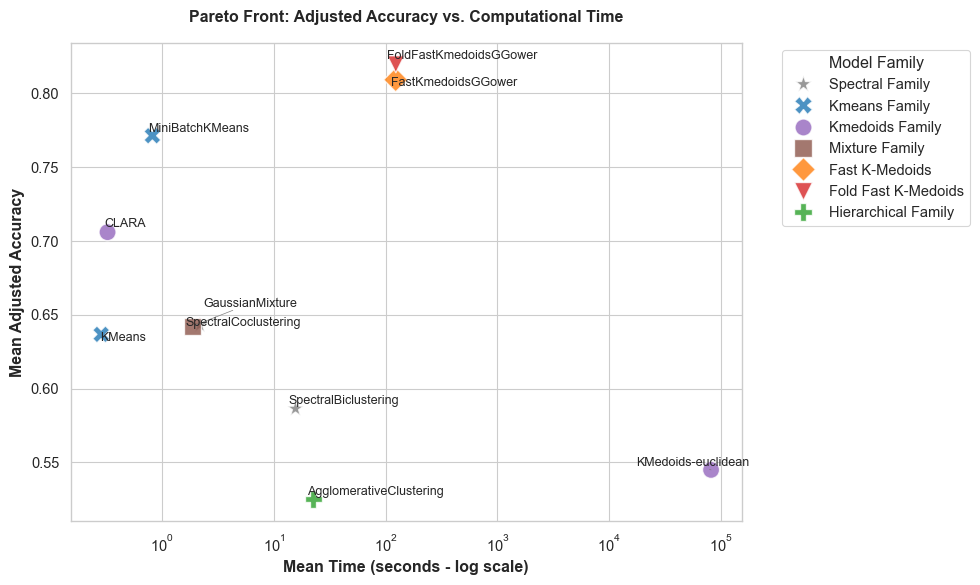

In [12]:
plot_pareto_front(df=df_results, models_to_plot=MODELS_TO_PLOT)

In [13]:
df_results_avg = df_results.group_by(['model_name']).agg(
    pl.col('mean_adj_accuracy').mean().alias('mean_adj_accuracy'),
    pl.col('mean_ari').mean().alias('mean_ari'),
    pl.col('mean_time').mean().alias('mean_time'),
    pl.col('std_adj_accuracy').mean().alias('std_adj_accuracy'),
    pl.col('std_ari').mean().alias('std_ari'),
    pl.col('std_time').mean().alias('std_time'),
).sort(
    by='mean_adj_accuracy', descending=True
).drop_nulls()

model_names = df_results_avg['model_name'].unique().to_list()
our_methods_1 = [x for x in model_names if 'Fast' in x and 'Fold' not in x] # Fast k-medoids
our_methods_2 = [x for x in model_names if 'Fast' in x and 'Fold' in x] # q-Fold Fast k-medoids
other_methods = [x for x in model_names if x not in our_methods_1 + our_methods_2]

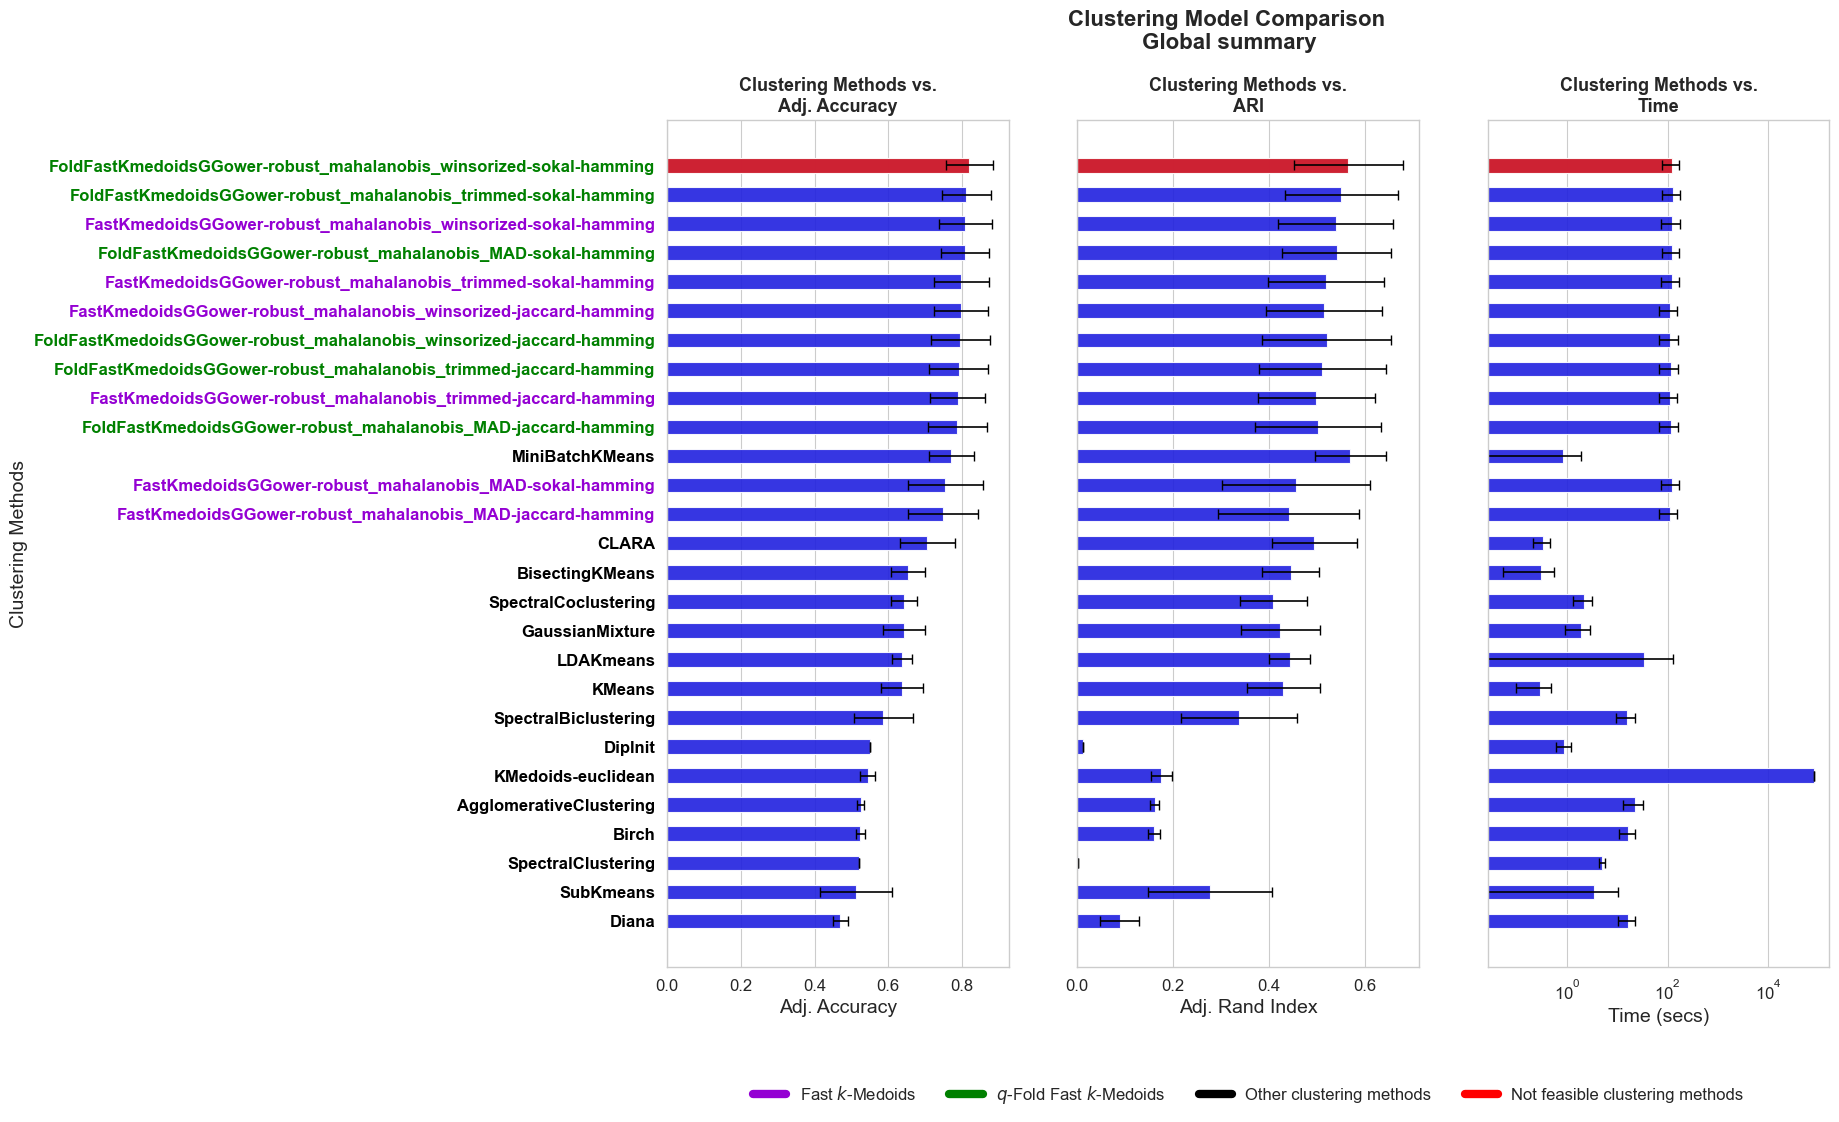

In [14]:
plot_experiment_5_results(df_avg=df_results_avg, data_name='Global Summary', num_realizations=None, 
                          time_log_scale=True, save_path=None, 
                          our_methods_1=our_methods_1, our_methods_2=our_methods_2, 
                          other_methods=other_methods, not_feasible_methods=None)

In [98]:
import polars as pl
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def plot_topological_resilience(df, models_to_plot):

    models_list = list(models_to_plot.keys())
    
    # Filtramos modelos y nos quedamos solo con las ejecuciones sin error
    df_valid = df.filter(
        (pl.col("model_name").is_in(models_list)) & 
        (pl.col("prop_status_error") < 1.0)
    ).to_pandas() # Pasamos a pandas para usar la función melt
    
    df_valid['Model'] = df_valid['model_name'].map(models_to_plot)
    
    # 3. Definir las métricas topológicas que irán en el Eje X
    metrics_map = {
        'prop_categorical': 'Proportion of Categorical Vars',
        'sphericity_quant': 'Cluster Sphericity (1 = Spherical)',
        'prop_redundancy_quant': 'Quantitative Redundancy',
        'prop_high_corr_quant': 'Quantitative High Correlation',
        'mean_prop_outliers_quant': 'Proportion of Outliers',
        'n_rows': 'Data Size',
        'n_clusters': 'Number of Clusters',
        'separation_factor': 'Clusters Separation',
        'normalized_balance_entropy': 'Clusters Balance'
    }
    
    # Derretir el DataFrame (formato largo) para el FacetGrid de Seaborn
    df_melted = pd.melt(
        df_valid,
        id_vars=['data_id', 'Model', 'mean_adj_accuracy'],
        value_vars=list(metrics_map.keys()),
        var_name='Metric_Code',
        value_name='Metric_Value'
    )
    
    # Mapear los nombres bonitos para los títulos de los gráficos
    df_melted['Metric_Name'] = df_melted['Metric_Code'].map(metrics_map)
    df_melted = df_melted.dropna(subset=['Metric_Value', 'mean_adj_accuracy'])
    
    # 4. Configurar el gráfico modo Paper
    sns.set_theme(style="whitegrid", context="paper", font_scale=1.2)
    
    # Paleta de colores: Tus modelos destacan (rojo/naranja), el resto en tonos más fríos
    custom_palette = {
        'Fold Fast KMedoids': '#d62728',
        'Fast KMedoids': '#ff7f0e',
        'MiniBatchKMeans': '#1f77b4',
        'KMeans': "#e226a9",
        'GMM': '#8c564b',
        'Agglomerative': '#2ca02c',
        'KMedoids-pam': "#e7ea13"
    }

    # 5. Dibujar el FacetGrid con Regresión LOESS
    g = sns.lmplot(
        data=df_melted,
        x="Metric_Value", 
        y="mean_adj_accuracy", 
        hue="Model",
        col="Metric_Name", 
        col_wrap=2,          # Matriz de 2x2
        lowess=True,         # Magia estadística: curvas suavizadas no lineales
        scatter=True,        # Mostramos los puntos reales como un "polvo" de fondo
        scatter_kws={'alpha': 1, 's': 20, 'edgecolor': 'none'}, 
        line_kws={'linewidth': 3},
        facet_kws={'sharex': False, 'sharey': True}, # Comparten Y (Accuracy) pero X es independiente
        height=4.5, 
        aspect=1.2,
        palette=custom_palette
    )

    # 6. Pulir detalles estéticos
    g.set_axis_labels("Metric Value", "Mean Adjusted Accuracy", weight='bold')
    g.set_titles("{col_name}", weight='bold') # El título de cada subgráfico es el nombre de la métrica
    
    # Ajustar la leyenda global
    sns.move_legend(g, "upper center", bbox_to_anchor=(0.5, 1.03), ncol=3, title=None, frameon=True)
    plt.tight_layout()
    
    # Guardar para el artículo
    # plt.savefig('topological_resilience_curves.pdf', format='pdf', dpi=300, bbox_inches='tight')
    plt.show()

In [99]:
MODELS_TO_PLOT = {
        'FoldFastKmedoidsGGower-robust_mahalanobis_winsorized-sokal-hamming': 'Fold Fast KMedoids',
        'FastKmedoidsGGower-robust_mahalanobis_winsorized-sokal-hamming': 'Fast KMedoids',
        'MiniBatchKMeans': 'MiniBatchKMeans',
        'KMeans': 'KMeans',
        'GaussianMixture': 'GMM',
        #'AgglomerativeClustering': 'Agglomerative',
        'KMedoids-euclidean': 'KMedoids-pam'
    }

c:\Users\fscielzo\Documents\PhD\paper-2\paper-code\.venv\Lib\site-packages\statsmodels\nonparametric\smoothers_lowess.py:226: RuntimeWarning: invalid value encountered in divide
  res, _ = _lowess(y, x, x, np.ones_like(x),


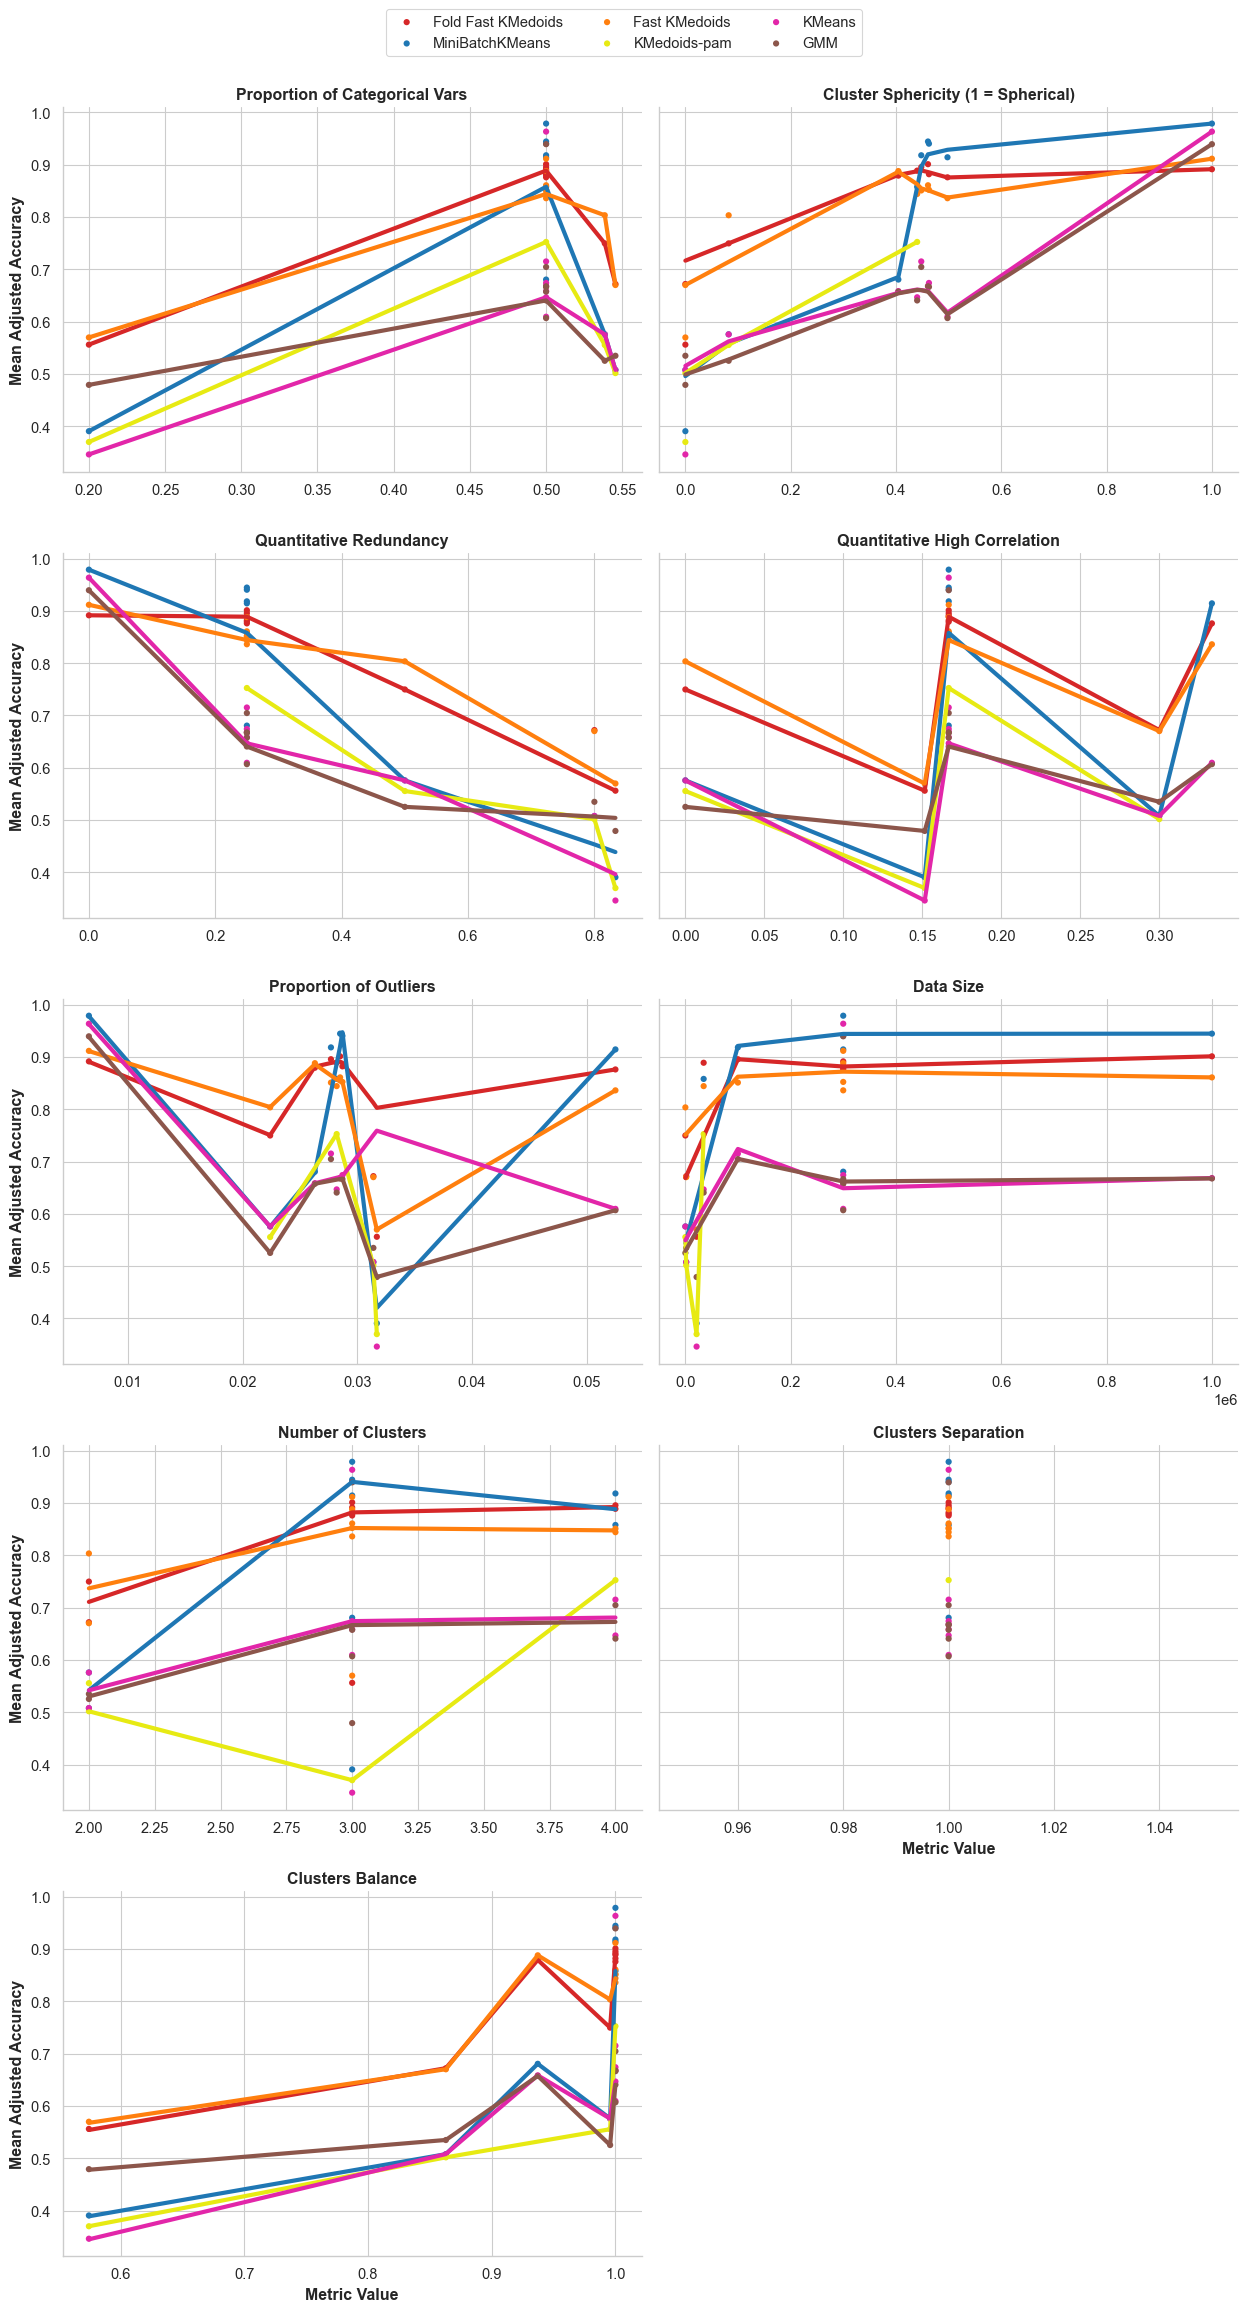

In [100]:
plot_topological_resilience(df=df_results, models_to_plot=MODELS_TO_PLOT)